<a href="https://colab.research.google.com/github/KekeliIsHere/galamsey-detection-ml/blob/main/galamsey_detector_training_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/KekeliIsHere/galamsey-detection-ml.git

Cloning into 'galamsey-detection-ml'...
remote: Enumerating objects: 438, done.
remote: Counting objects: 100% (438/438), done.
remote: Compressing objects: 100% (433/433), done.
remote: Total 438 (delta 3), reused 427 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (438/438), 34.48 MiB | 41.78 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

The whole "*tf.keras.preprocessing.image_dataset_from_directory*" generates a **tf.data.Dataset**

This is what the arguments mean:

**validation_split**->Optional float between 0 and 1, fraction of data to reserve for validation.

**subset**->Subset of the data to return. One of "training", "validation", or "both".

**seed**->	Optional random seed for shuffling and transformations.

**batch_size**->Size of the batches of data. Defaults to 32. Instead 80 images at once, the model sees 8 images at a time




In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "galamsey-detection-ml/Phase 1/dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=8
)

validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "galamsey-detection-ml/Phase 1/dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=8
)

Found 100 files belonging to 2 classes.
Using 80 files for training.
Found 100 files belonging to 2 classes.
Using 20 files for validation.


In [4]:
#Normalizaation. Helps the NN learn better
normalization_layer = layers.Rescaling(1./255)

dataset = dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

In [5]:
#Loading Up Pre-Trained Model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

# freeze only early layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
#Classifier
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

In [7]:
#Compiling
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
layers.Dense(1, activation='sigmoid')

<Dense name=dense_1, built=False>

In [8]:
#Training the Model
history = model.fit(
    dataset,
    validation_data=validation_dataset,
    epochs=10
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.9000 - loss: 0.2668 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9875 - loss: 0.0806 - val_accuracy: 1.0000 - val_loss: 2.8252e-06
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9625 - loss: 0.0847 - val_accuracy: 0.9500 - val_loss: 0.3131
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.0126 - val_accuracy: 0.9000 - val_loss: 0.9460
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0208 - val_accuracy: 1.0000 - val_loss: 0.0304
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9875 - loss: 0.0480 - val_accuracy: 0.9000 - val_loss: 1.0755
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8000 - val_loss: 1.8168
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9375 - loss: 0.1515 - val_accuracy: 0.7500 

In [9]:
model.save("galamsey_detector_model.h5")

In [39]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

dataset = dataset.map(lambda x, y: (data_augmentation(x), y))

In [24]:
from google.colab import files
files.download("galamsey_detector_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Testing new images and thing
import numpy as np
from tensorflow.keras.preprocessing import image

# Load the image
img = image.load_img("new_patch.png", target_size=(224,224))  # resize to same as training
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension
img_array = img_array / 255.0  # normalize like training

# Predict
prediction = model.predict(img_array)
print(prediction)

# Convert to class
if prediction[0][0] > 0.5:
    print("Galamsey detected!")
else:
    print("No galamsey detected!")

In [11]:
from google.colab import files
uploaded = files.upload()

Saving galamsey_area.jpg to galamsey_area.jpg


/tmp/ipykernel_3265/2979344425.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p = float(p)


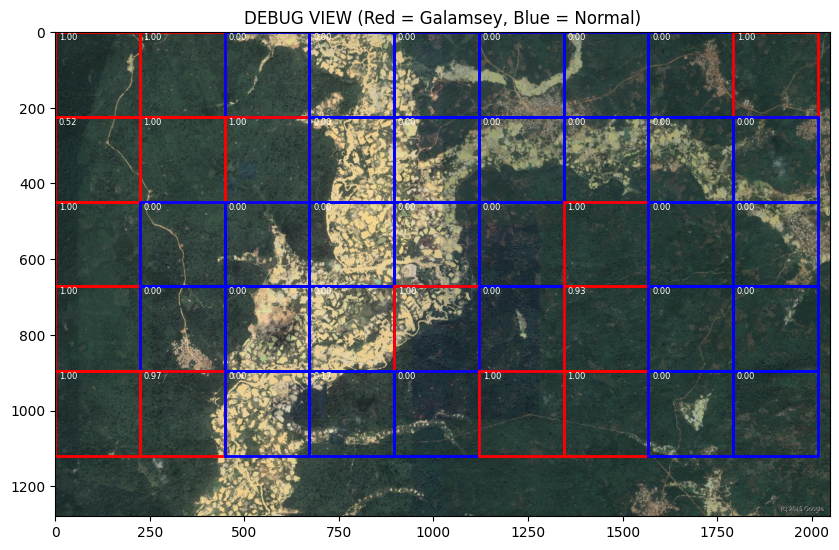

In [12]:
import tensorflow as tf
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# load model
model = tf.keras.models.load_model("galamsey_detector_model.h5", compile=False)

# load image
img = Image.open("galamsey_area.jpg").convert("RGB")
width, height = img.size

tile_size = 224

tiles = []
positions = []

# split image
for y in range(0, height - tile_size + 1, tile_size):
    for x in range(0, width - tile_size + 1, tile_size):
        tile = img.crop((x, y, x+tile_size, y+tile_size))
        tiles.append(tile)
        positions.append((x, y))

# preprocess
X = np.array([np.array(t)/255.0 for t in tiles], dtype=np.float32)

# predict
preds = model.predict(X, verbose=0)

# visualize EVERYTHING (no filtering)
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(img)

for (x, y), p in zip(positions, preds):
    p = float(p)

    # color based on value
    if p > 0.5:
        color = 'red'   # predicted galamsey
    else:
        color = 'blue'  # predicted normal

    rect = patches.Rectangle(
        (x,y), tile_size, tile_size,
        linewidth=2,
        edgecolor=color,
        facecolor='none'
    )
    ax.add_patch(rect)

    # print value on tile
    ax.text(x+10, y+20, f"{p:.2f}", color='white', fontsize=6)

plt.title("DEBUG VIEW (Red = Galamsey, Blue = Normal)")
plt.show()